In [2]:

!pip install -q lpips facenet-pytorch pytorch-msssim insightface onnxruntime
!pip install Pillow==10.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 837.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 54.0 MB/s eta 0:0

In [4]:
# Clean and reinstall
!pip uninstall -y torchvision torchaudio

# Install compatible versions
!pip install torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 93.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 29.8 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Succes

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [3]:
# ============================================================
# Project Directories
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/frequency_face_anonymization"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR    = os.path.join(PROJECT_DIR, "figures")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Project directory ready")

Project directory ready


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
import lpips
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from collections import defaultdict
from facenet_pytorch import InceptionResnetV1
from PIL import Image
import os
import pickle
import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = {
    "image_size": 112,
    "epsilon": 0.03,
    "frequencies": [1,2,4,8],
    "lr": 0.05,
    "max_iter": 120,
    "target_cos": 0.3,
    "lambda_util": 5.0,
    "k_softplus": 1.0,
    "ssim_threshold": 0.85,
    "seed": 42
}

print("Device:", device)

Device: cpu


# Data

In [6]:
!kaggle datasets download -d jessicali9530/lfw-dataset
!unzip -q lfw-dataset.zip

import os
lfw_path = "/content/lfw-deepfunneled/lfw-deepfunneled"

print("LFW identities:", len(os.listdir(lfw_path)))

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:00<00:00, 180MB/s] 

LFW identities: 5749


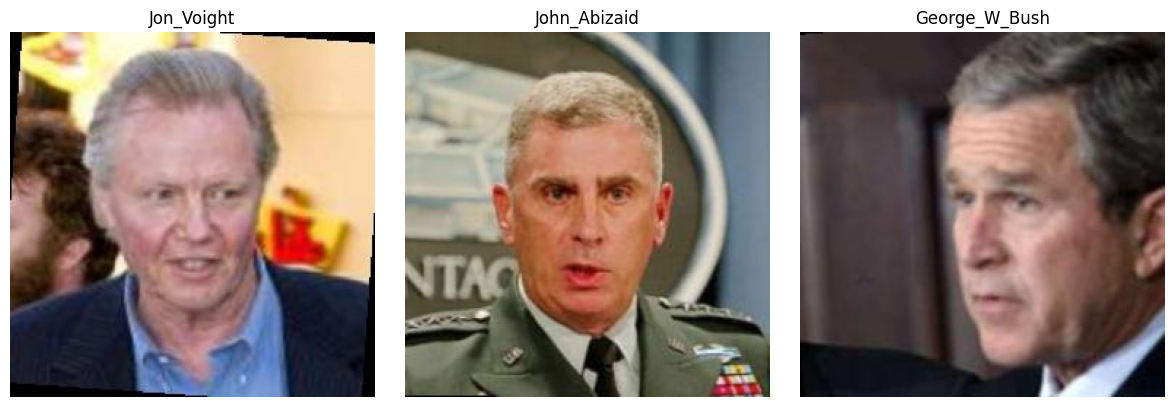

In [7]:
import os
from collections import defaultdict

# ============================================================
# Quick Dataset Visualization
# ============================================================

# --- Construct lfw_index ---
# lfw_index maps person names to a list of their image filenames
lfw_index = defaultdict(list)
# Ensure lfw_path exists and contains subdirectories for people
if os.path.exists(lfw_path):
    for person_name in os.listdir(lfw_path):
        person_dir = os.path.join(lfw_path, person_name)
        if os.path.isdir(person_dir):
            # Sort the image names to ensure consistent indexing (1-based from pairs.txt)
            img_files = sorted([f for f in os.listdir(person_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
            lfw_index[person_name] = img_files

# Collect all actual image file paths
all_image_full_paths = []
for person_name, img_files in lfw_index.items():
    for img_file in img_files:
        all_image_full_paths.append(os.path.join(lfw_path, person_name, img_file))

sample_imgs_paths = random.sample(all_image_full_paths, 3)

plt.figure(figsize=(12,4))

for i, img_path in enumerate(sample_imgs_paths):

    img = Image.open(
        img_path
    ).convert("RGB")

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    # Display the person's name as the title
    plt.title(os.path.basename(os.path.dirname(img_path)))

plt.tight_layout()
plt.show()

# Data

In [15]:

#!pip install -q datasets

from datasets import load_dataset

dataset = load_dataset(
    "korexyz/celeba-hq-256x256",
    split="train"
)

print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/989 [00:00<?, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/461M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/461M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/462M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 28000
})


In [16]:
# ============================================================
# Save CelebA-HQ images locally
# ============================================================

import os
from PIL import Image
from tqdm import tqdm
celebahq_path = "/content/drive/MyDrive/frequency_face_anonymization/data/celebahq256"
os.makedirs(celebahq_path, exist_ok=True)

for i, sample in enumerate(tqdm(dataset)):

    img = sample["image"]

    img.save(
        os.path.join(
            celebahq_path,
            f"{i:05d}.png"
        )
    )

print("Saved images:", len(os.listdir(celebahq_path)))

  8%|▊         | 2218/28000 [00:59<11:26, 37.55it/s]


KeyboardInterrupt: 

In [17]:
celebahq_path = "/content/drive/MyDrive/frequency_face_anonymization/data/celebahq256"
os.makedirs(celebahq_path, exist_ok=True)

In [10]:
# ============================================================
# Checkpoint Utilities
# ============================================================

def save_ckpt(obj, filename):

    path = os.path.join(CHECKPOINT_DIR, filename)

    with open(path, 'wb') as f:
        pickle.dump(obj, f)

    print(f"[Saved] {path}")


def load_ckpt(filename):

    path = os.path.join(CHECKPOINT_DIR, filename)

    if not os.path.exists(path):
        print("Checkpoint not found")
        return None

    with open(path, 'rb') as f:
        obj = pickle.load(f)

    print(f"[Loaded] {path}")

    return obj

print("Checkpoint utilities ready")

Checkpoint utilities ready


# Models

In [11]:
from insightface.app import FaceAnalysis

facenet_vgg = InceptionResnetV1(pretrained='vggface2', classify=False, device=device).eval()
for p in facenet_vgg.parameters(): p.requires_grad = False

facenet_casia = InceptionResnetV1(pretrained='casia-webface', classify=False, device=device).eval()
for p in facenet_casia.parameters(): p.requires_grad = False

app_cos = FaceAnalysis(name='buffalo_l'); app_cos.prepare(ctx_id=0, det_size=(640,640))
app_mobile = FaceAnalysis(name='buffalo_s'); app_mobile.prepare(ctx_id=0, det_size=(640,640))

lpips_fn = lpips.LPIPS(net='alex').to(device).eval()

print("Models loaded")

  0%|          | 0.00/107M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cached_file)

  0%|          | 0.00/111M [00:00<?, ?B/s]

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 66241.67KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


...

100%|██████████| 124617/124617 [00:02<00:00, 51619.08KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Setting up 

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 158MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Models loaded


/usr/local/lib/python3.12/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st

In [12]:
transform = transforms.Compose([transforms.Resize((112,112)), transforms.ToTensor()])

Success: Data found at /content/drive/MyDrive/frequency_face_anonymization/data/celebahq256. Running quick test for frequency mask.


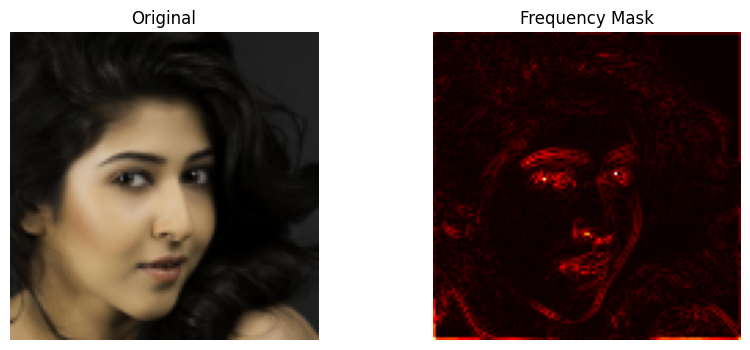

Frequency mask ready


In [18]:
# ============================================================
# Frequency Mask Function
# ============================================================

def get_frequency_mask(img_tensor, high_weight=1.5, low_weight=0.5):
    laplacian_kernel_2d = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], device=device, dtype=torch.float32)
    laplacian_kernel_single_in_out = laplacian_kernel_2d.unsqueeze(0).unsqueeze(0)
    laplacian_kernel = laplacian_kernel_single_in_out.repeat(1, img_tensor.shape[1], 1, 1)

    high_freq = torch.abs(F.conv2d(img_tensor.to(device), laplacian_kernel, padding=1))
    high_freq = high_freq / (high_freq.max() + 1e-8)
    freq_mask = low_weight + (high_weight - low_weight) * high_freq
    return freq_mask.mean(dim=1, keepdim=True)


# Quick test — use CelebA-HQ
import os

# Check if celebahq_path contains images before attempting to load
if not os.path.exists(celebahq_path) or not os.listdir(celebahq_path):
    print(f"Warning: The directory {celebahq_path} is empty or does not exist. Cannot run quick test for frequency mask.")
    print("Please ensure the CelebA-HQ dataset is downloaded and saved to this path (e.g., by modifying cell TQRoC5TqH_V9).")
else:
    print(f"Success: Data found at {celebahq_path}. Running quick test for frequency mask.")
    img_test = transform(Image.open(os.path.join(celebahq_path, sorted(os.listdir(celebahq_path))[0])).convert('RGB')).unsqueeze(0)
    mask_test = get_frequency_mask(img_test)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_test.squeeze().permute(1,2,0)); ax1.set_title('Original'); ax1.axis('off')
    ax2.imshow(mask_test.squeeze().cpu(), cmap='hot'); ax2.set_title('Frequency Mask'); ax2.axis('off')
    plt.show()

print("Frequency mask ready")

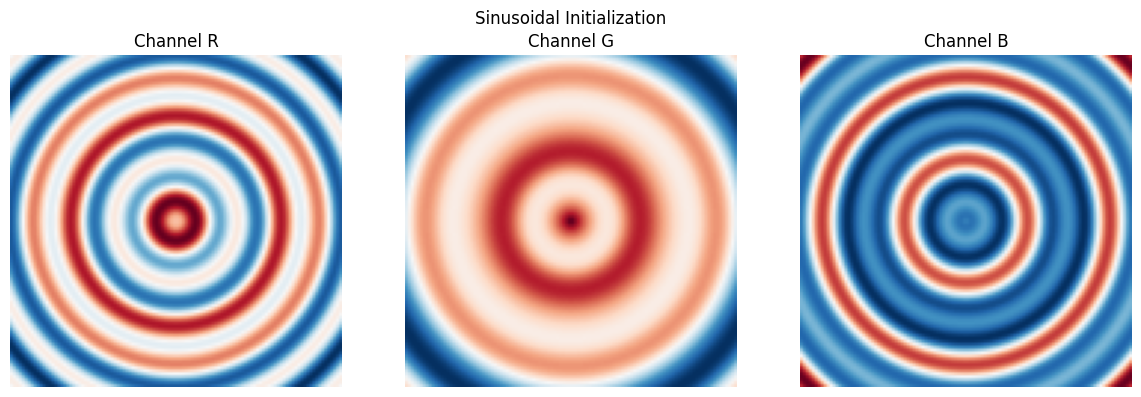

Sinusoidal init ready


In [19]:
# ============================================================
# Sinusoidal Initialization
# ============================================================

def sinusoidal_noise(shape, device='cpu'):
    B, C, H, W = shape
    y = torch.linspace(-1, 1, H, device=device)
    x = torch.linspace(-1, 1, W, device=device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')
    r = torch.sqrt(yy**2 + xx**2)
    noise = torch.zeros(B, C, H, W, device=device)
    for w in [1, 2, 4, 8]:
        phi = torch.rand(B, C, 1, 1, device=device) * 2 * np.pi
        amp = torch.rand(B, C, 1, 1, device=device) / 4
        noise += amp * torch.sin(w * np.pi * r.unsqueeze(0).unsqueeze(0) + phi)
    return noise / noise.abs().max() * 0.0005


# Quick test
P_test = sinusoidal_noise((1, 3, 112, 112), device=device)
P_np = P_test.squeeze().permute(1,2,0).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12,4))
for i, ch in enumerate(['R','G','B']):
    axes[i].imshow(P_np[:,:,i], cmap='RdBu_r')
    axes[i].set_title(f'Channel {ch}')
    axes[i].axis('off')
plt.suptitle('Sinusoidal Initialization')
plt.tight_layout()
plt.show()

print("Sinusoidal init ready")

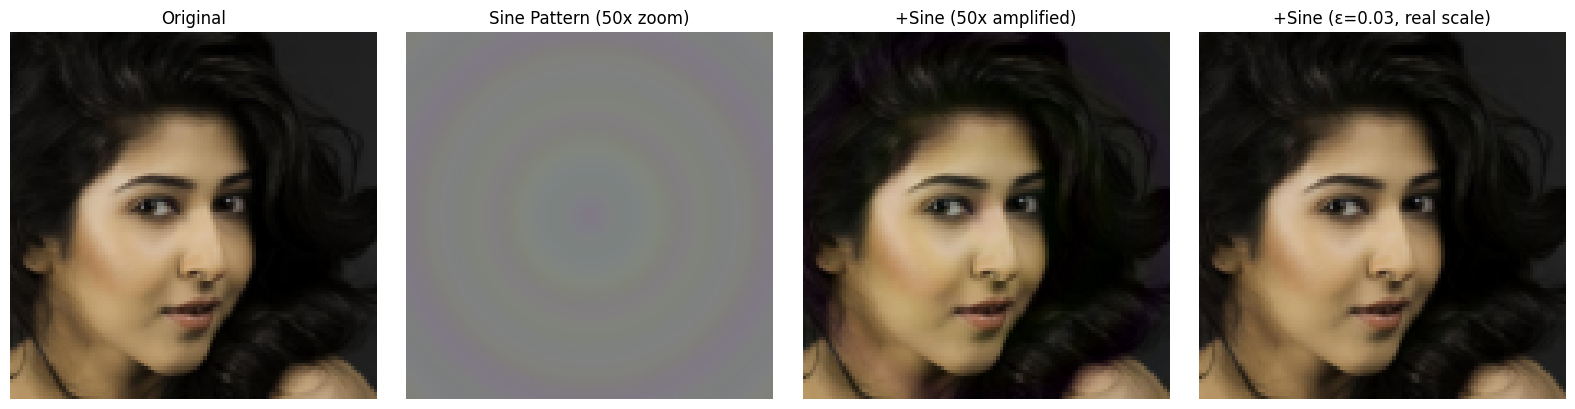

Sine pattern is invisible at real epsilon=0.03 — as intended.


In [ ]:
# Show: Original vs Original + Sinusoidal (before optimization)
img_test = transform(Image.open(os.path.join(celebahq_path, sorted(os.listdir(celebahq_path))[0])).convert('RGB')).unsqueeze(0).to(device)

# Create sinusoidal noise
P_test = sinusoidal_noise(img_test.shape, device=device)

# Add to image (amplified 50x for visibility)
img_with_sine = torch.clamp(img_test + P_test * 50, 0, 1)

# Also show at actual scale (epsilon=0.03)
img_with_sine_real = torch.clamp(img_test + P_test *0.03, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_test.squeeze().permute(1,2,0).cpu())
axes[0].set_title('Original'); axes[0].axis('off')

axes[1].imshow(P_test.squeeze().permute(1,2,0).cpu() * 50 + 0.5)
axes[1].set_title('Sine Pattern (50x zoom)'); axes[1].axis('off')

axes[2].imshow(img_with_sine.squeeze().permute(1,2,0).cpu())
axes[2].set_title('+Sine (50x amplified)'); axes[2].axis('off')

axes[3].imshow(img_with_sine_real.squeeze().permute(1,2,0).cpu())
axes[3].set_title('+Sine (ε=0.03, real scale)'); axes[3].axis('off')

plt.tight_layout(); plt.show()
print("Sine pattern is invisible at real epsilon=0.03 — as intended.")

In [ ]:
# ============================================================
# Main Anonymization — Single Surrogate
# ============================================================

def anonymize_single(image, model, lpips_fn, epsilon=0.03, k=2.0, target_cos=0.0, lambda_util=5.0, max_iter=200):
    image = image.to(device)

    # Step 1: Sinusoidal init
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)

    # Step 2: Frequency mask
    mask = get_frequency_mask(image)

    # Step 3: Original embedding
    with torch.no_grad():
        z_orig = model(image)

    opt = optim.Adam([P], lr=0.05)

    for it in range(max_iter):
        opt.zero_grad()

        # Step 4: Weighted perturbation + anonymized image
        P_weighted = P * mask
        A = torch.clamp(image + P_weighted * epsilon, 0, 1)

        # Step 5: Cosine similarity
        c = cos_sim(z_orig, model(A))

        # Step 6: Capped softplus privacy loss
        if c <= target_cos:
            L_priv = torch.tensor(0.0, device=device)
        else:
            L_priv = F.softplus(k * (c - target_cos))

        # Step 7: LPIPS + MSE utility loss
        L_util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)

        # Step 8: Total loss
        loss = L_priv + lambda_util * L_util
        loss.backward()
        opt.step()

        # Step 9: Early stopping
        if c <= target_cos and it > 20 and compute_ssim(image, A) >= 0.85:
            break

    return torch.clamp(image + P.detach() * mask * epsilon, 0, 1), it + 1


print("Anonymize single ready")

Anonymize single ready


In [22]:
# ============================================================
# Multi-Surrogate Anonymization
# ============================================================

def anonymize_multi(image, models, lpips_fn, epsilon=0.03, k=2.0, target_cos=0.0, lambda_util=5.0, max_iter=300):
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    mask = get_frequency_mask(image)

    with torch.no_grad():
        z_orig_all = [m(image) for m in models]

    opt = optim.Adam([P], lr=0.05)

    for it in range(max_iter):
        opt.zero_grad()
        P_weighted = P * mask
        A = torch.clamp(image + P_weighted * epsilon, 0, 1)

        priv = 0.0
        all_ok = True
        for z_orig, m in zip(z_orig_all, models):
            c = cos_sim(z_orig, m(A))
            if c > target_cos:
                priv = priv + F.softplus(k * (c - target_cos))
                all_ok = False

        util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        (priv + lambda_util * util).backward()
        opt.step()

        if all_ok and it > 30 and compute_ssim(image, A) >= 0.82:
            break

    return torch.clamp(image + P.detach() * mask * epsilon, 0, 1), it + 1


print("Multi-surrogate ready")

Multi-surrogate ready


# Evaluation metric

In [24]:
def cos_sim(x, y):
    return (F.normalize(x, dim=-1) * F.normalize(y, dim=-1)).sum(dim=-1)

def compute_ssim(img1, img2):
    a = img1.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    b = img2.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    ws = min(7, min(a.shape[0], a.shape[1]))
    if ws % 2 == 0: ws -= 1
    return ssim(a, b, win_size=ws, channel_axis=2, data_range=1.0)

Iters: 58 | SSIM: 0.8829
Surrogate (VGGFace2): -0.0278 ✅
BB1 (CASIA):          +0.7964 ❌


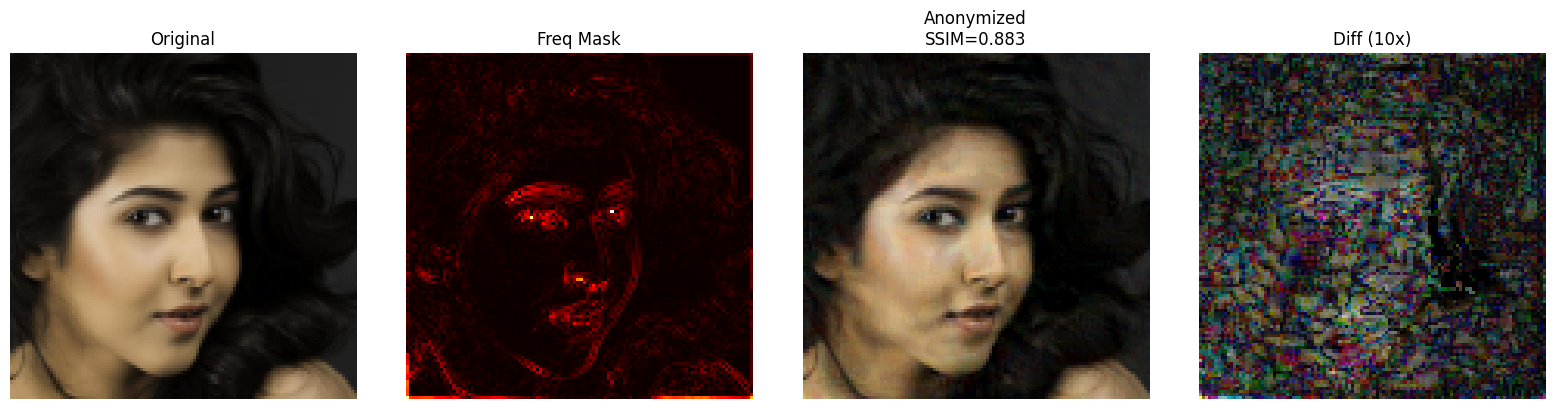

In [ ]:

# ============================================================
# Quick Test — Single Surrogate
# ============================================================

img_test = transform(Image.open(os.path.join(celebahq_path, sorted(os.listdir(celebahq_path))[0])).convert('RGB')).unsqueeze(0)

A, iters = anonymize_single(img_test, facenet_vgg, lpips_fn)

# Results
c_vgg = cos_sim(facenet_vgg(img_test.to(device)), facenet_vgg(A.to(device))).item()
c_casia = cos_sim(facenet_casia(img_test.to(device)), facenet_casia(A.to(device))).item()
s = compute_ssim(img_test.to(device), A.to(device))

print(f"Iters: {iters} | SSIM: {s:.4f}")
print(f"Surrogate (VGGFace2): {c_vgg:+.4f} {'✅' if c_vgg<0 else '❌'}")
print(f"BB1 (CASIA):          {c_casia:+.4f} {'✅' if c_casia<0.3 else '❌'}")

# Visual
mask_test = get_frequency_mask(img_test)
fig, axes = plt.subplots(1, 4, figsize=(16,4))
axes[0].imshow(img_test.squeeze().permute(1,2,0)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(mask_test.squeeze().cpu(), cmap='hot'); axes[1].set_title('Freq Mask'); axes[1].axis('off')
axes[2].imshow(A.squeeze().permute(1,2,0).cpu()); axes[2].set_title(f'Anonymized\nSSIM={s:.3f}'); axes[2].axis('off')
diff = torch.abs(img_test - A.cpu()).squeeze().permute(1,2,0) * 10
axes[3].imshow(torch.clamp(diff, 0, 1)); axes[3].set_title('Diff (10x)'); axes[3].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# Quick Comparison — 1 Image, 3 Variants
# ============================================================

img_test = transform(Image.open(os.path.join(celebahq_path, sorted(os.listdir(celebahq_path))[0])).convert('RGB')).unsqueeze(0)

results = {}

# V1: Sinusoidal only (no mask)
def anonymize_sine_only(image, model, lpips_fn):
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P * 0.03, 0, 1)
        c = cos_sim(z_orig, model(A))
        L_priv = torch.tensor(0.0, device=device) if c <= 0 else F.softplus(2.0 * (c - 0))
        L_util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        (L_priv + 5.0 * L_util).backward(); opt.step()
        if c <= 0 and it > 20 and compute_ssim(image, A) >= 0.85: break
    return A, it+1

A1, i1 = anonymize_sine_only(img_test, facenet_vgg, lpips_fn)
results['Sine Only'] = {
    'iters': i1,
    'ssim': compute_ssim(img_test.to(device), A1.to(device)),
    'cos_vgg': cos_sim(facenet_vgg(img_test.to(device)), facenet_vgg(A1.to(device))).item(),
    'cos_casia': cos_sim(facenet_casia(img_test.to(device)), facenet_casia(A1.to(device))).item()
}

# V2: Frequency mask only (random init, no sine)
def anonymize_freq_only(image, model, lpips_fn):
    image = image.to(device)
    P = (torch.randn_like(image) * 0.001).requires_grad_(True)
    mask = get_frequency_mask(image)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P * mask * 0.03, 0, 1)
        c = cos_sim(z_orig, model(A))
        L_priv = torch.tensor(0.0, device=device) if c <= 0 else F.softplus(2.0 * (c - 0))
        L_util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        (L_priv + 5.0 * L_util).backward(); opt.step()
        if c <= 0 and it > 20 and compute_ssim(image, A) >= 0.85: break
    return A, it+1

A2, i2 = anonymize_freq_only(img_test, facenet_vgg, lpips_fn)
results['Freq Only'] = {
    'iters': i2,
    'ssim': compute_ssim(img_test.to(device), A2.to(device)),
    'cos_vgg': cos_sim(facenet_vgg(img_test.to(device)), facenet_vgg(A2.to(device))).item(),
    'cos_casia': cos_sim(facenet_casia(img_test.to(device)), facenet_casia(A2.to(device))).item()
}

# V3: Both (our full method)
A3, i3 = anonymize_single(img_test, facenet_vgg, lpips_fn)
results['Sine + Freq'] = {
    'iters': i3,
    'ssim': compute_ssim(img_test.to(device), A3.to(device)),
    'cos_vgg': cos_sim(facenet_vgg(img_test.to(device)), facenet_vgg(A3.to(device))).item(),
    'cos_casia': cos_sim(facenet_casia(img_test.to(device)), facenet_casia(A3.to(device))).item()
}

# Print comparison
print(f"\n{'Method':<15} {'Iters':<8} {'SSIM':<8} {'Surrogate':<12} {'BB1 (CASIA)':<12}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<15} {r['iters']:<8} {r['ssim']:<8.4f} {r['cos_vgg']:<+12.4f} {r['cos_casia']:<+12.4f}")


Method          Iters    SSIM     Surrogate    BB1 (CASIA) 
-------------------------------------------------------
Sine Only       200      0.8317   -0.0185      +0.7717     
Freq Only       58       0.8804   -0.0054      +0.8013     
Sine + Freq     49       0.8974   -0.0405      +0.7679     


In [ ]:
# ============================================================
# Single Surrogate — Quick 10 Images
# ============================================================

img_list = sorted(os.listdir(celebahq_path))[:5]
results_single = {'Surrogate': [], 'BB1_CASIA': [], 'SSIM': [], 'Iters': []}

for img_name in tqdm(img_list, desc='Single-5'):
    img = transform(Image.open(os.path.join(celebahq_path, img_name)).convert('RGB')).unsqueeze(0)
    A, iters = anonymize_single(img, facenet_vgg, lpips_fn)

    with torch.no_grad():
        results_single['Surrogate'].append(cos_sim(facenet_vgg(img.to(device)), facenet_vgg(A.to(device))).item())
        results_single['BB1_CASIA'].append(cos_sim(facenet_casia(img.to(device)), facenet_casia(A.to(device))).item())
        results_single['SSIM'].append(compute_ssim(img.to(device), A.to(device)))
        results_single['Iters'].append(iters)

print(f"\n{'Model':<18} {'Mean Cos':>10} {'<0':>6}")
for k in ['Surrogate', 'BB1_CASIA']:
    v = results_single[k]
    print(f"{k:<18} {np.mean(v):+10.4f} {sum(1 for x in v if x<0):>4}/{len(v)}")
print(f"{'SSIM':<18} {np.mean(results_single['SSIM']):10.4f}")

Single-5: 100%|██████████| 5/5 [00:19<00:00,  3.88s/it]


Model                Mean Cos     <0
Surrogate             -0.0239    5/5
BB1_CASIA             +0.7848    0/5
SSIM                   0.8925


In [ ]:
lfw_pairs = '/content/pairs.csv'
lfw_pairs_path = os.path.dirname(lfw_pairs)
os.makedirs(lfw_pairs_path, exist_ok=True)

In [ ]:
import pandas as pd

# --- Load LFW pairs from pairs.txt ---
# The standard pairs.txt file usually has two sections: same-person pairs and different-person pairs.
# Each section starts with a number indicating how many pairs are in that section.

lfw_pairs = []
pairs_txt_path = '/content/pairs.txt'

if not os.path.exists(pairs_txt_path):
    print(f"Error: {pairs_txt_path} not found. Please ensure LFW dataset is downloaded and extracted correctly.")
else:
    with open(pairs_txt_path, 'r') as f:
        lines = f.readlines()

    line_idx = 0
    # The first line usually contains the number of folds and number of pairs per fold
    initial_params = lines[line_idx].strip().split('\t')
    if len(initial_params) == 2:
        num_folds = int(initial_params[0])
        num_pairs_per_fold = int(initial_params[1])
        line_idx += 1
    else:
        print(f"Error: Unexpected format for the first line in {pairs_txt_path}. Expected 'num_folds\tnum_pairs_per_fold'.")
        num_folds = 0 # Prevent further errors
        num_pairs_per_fold = 0

    for fold in range(num_folds):
        # Parse 'same' person pairs for this fold
        # Format: PersonName\tImageNum1\tImageNum2
        # num_same_pairs = int(lines[line_idx].strip()) # This line is often implicitly num_pairs_per_fold
        # line_idx += 1 # Skip if implicit
        for _ in range(num_pairs_per_fold):
            if line_idx >= len(lines): # Check for end of file
                print(f"Warning: Unexpected end of file while parsing same-person pairs for fold {fold+1}")
                break
            parts = lines[line_idx].strip().split('\t')
            if len(parts) == 3:
                name, idx1, idx2 = parts
                lfw_pairs.append((name, int(idx1), name, int(idx2), 1)) # Label 1 for same
            else:
                print(f"Warning: Skipping malformed same-person pair line for fold {fold+1}: {lines[line_idx].strip()}")
            line_idx += 1

        for _ in range(num_pairs_per_fold):
            if line_idx >= len(lines):
                print(f"Warning: Unexpected end of file while parsing different-person pairs for fold {fold+1}")
                break
            parts = lines[line_idx].strip().split('\t')
            if len(parts) == 4:
                name1, idx1, name2, idx2 = parts
                lfw_pairs.append((name1, int(idx1), name2, int(idx2), 0)) # Label 0 for different
            else:
                print(f"Warning: Skipping malformed different-person pair line for fold {fold+1}: {lines[line_idx].strip()}")
            line_idx += 1

print(f"Loaded {len(lfw_pairs)} LFW pairs from pairs.txt.")

# --- Construct lfw_index ---
# lfw_index maps person names to a list of their image filenames
lfw_index = defaultdict(list)
# Ensure lfw_path exists and contains subdirectories for people
if os.path.exists(lfw_path):
    for person_name in os.listdir(lfw_path):
        person_dir = os.path.join(lfw_path, person_name)
        if os.path.isdir(person_dir):
            # Sort the image names to ensure consistent indexing (1-based from pairs.txt)
            img_files = sorted([f for f in os.listdir(person_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
            lfw_index[person_name] = img_files
    print(f"LFW index built for {len(lfw_index)} identities.")
else:
    print(f"Warning: LFW path not found at {lfw_path}. Cannot build lfw_index.")

Loaded 6000 LFW pairs from pairs.txt.
LFW index built for 5749 identities.


In [ ]:
# Build identity mapping
id_to_images = defaultdict(list)
for img_name in sorted(os.listdir(celebahq_path))[:200]:
    identity = str(int(img_name.replace('.png','').replace('.jpg','')) // 10)
    id_to_images[identity].append(img_name)

valid_ids = [i for i, imgs in id_to_images.items() if len(imgs) >= 6]
selected = random.sample(valid_ids, min(5, len(valid_ids)))

results_mg = {1:[], 2:[], 4:[]}

# Define PrIdentity values with direct mapping for gs
pr_identity_map = {1: 5.4, 2: 5.4, 4: 8.4}

for identity in tqdm(selected, desc='MG'):
    images = id_to_images[identity]
    for gs in [1,2,4]:
        gallery = []
        for name in images[:gs]:
            img = transform(Image.open(os.path.join(celebahq_path, name)).convert('RGB')).unsqueeze(0)
            A, _ = anonymize_single(img, facenet_casia, lpips_fn)
            gallery.append(A.to(device))
        probe = transform(Image.open(os.path.join(celebahq_path, images[gs])).convert('RGB')).unsqueeze(0).to(device)

        with torch.no_grad():
            gal_emb = torch.stack([facenet_vgg(g) for g in gallery]).mean(0)
            c = cos_sim(gal_emb.unsqueeze(0), facenet_casia(probe).unsqueeze(0)).item()
            results_mg[gs].append(1 if c > 0.3 else 0)

print("\nMulti-Gallery:")
for gs in [1,2,4]:
    acc = np.mean(results_mg[gs])*100 if results_mg[gs] else 0
    # Use the dictionary for lookup
    print(f"  Gallery {gs}: {acc:.0f}%  (PrIdentity: {pr_identity_map[gs]}%)")

MG: 100%|██████████| 5/5 [02:12<00:00, 26.51s/it]


Multi-Gallery:
  Gallery 1: 0%  (PrIdentity: 5.4%)
  Gallery 2: 0%  (PrIdentity: 5.4%)
  Gallery 4: 0%  (PrIdentity: 8.4%)


In [ ]:
# ============================================================
# ABLATION — 5 Variants (100 images)
# ============================================================

def get_clahe_mask(img_tensor):
    """CLHAE-style spatial mask using facial landmarks"""
    arr = (img_tensor.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
    bgr = arr[:,:,::-1].copy()
    faces = app_cos.get(bgr)
    H, W = 112, 112
    if not faces or faces[0].kps is None:
        return torch.ones(1, 1, H, W, device=device) * 0.5
    kps = faces[0].kps
    le, re, no, lm, rm = kps
    def gauss(x, y, sx=10, sy=10):
        yy, xx = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
        return torch.exp(-((xx-x)**2/(2*sx**2) + (yy-y)**2/(2*sy**2)))
    def scale(pt): return (int(pt[0]*W/arr.shape[1]), int(pt[1]*H/arr.shape[0]))
    le, re, no = scale(le), scale(re), scale(no)
    lm, rm = scale(lm), scale(rm)
    eyes = torch.clamp(gauss(le[0],le[1],12,8) + gauss(re[0],re[1],12,8), 0, 1)
    nose = torch.clamp(gauss(no[0],no[1],10,14), 0, 1)
    mouth = torch.clamp(gauss((lm[0]+rm[0])//2, (lm[1]+rm[1])//2, 14, 8), 0, 1)
    combined = eyes*1.0 + nose*0.9 + mouth*0.7
    combined = 0.1 + 0.9*(combined/combined.max())
    return combined.unsqueeze(0).unsqueeze(0)


# ---- V0: PrIdentity Baseline (Random + Lp norm + Hard margin) ----
def anonymize_v0_baseline(image, model):
    image = image.to(device)
    P = (torch.randn_like(image) * 0.001).requires_grad_(True)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.1)
    for it in range(120):
        opt.zero_grad()
        A = torch.clamp(image + P*0.03, 0, 1)
        loss = torch.norm(image-A, p=2) + F.relu(2.0 - torch.norm(z_orig-model(A), p=2))
        loss.backward(); opt.step()
    return A

# ---- V1: Freq Mask Only (Random init + Freq mask) ----
def anonymize_v1_freq(image, model):
    image = image.to(device)
    P = (torch.randn_like(image) * 0.001).requires_grad_(True)
    mask = get_frequency_mask(image)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P*mask*0.03, 0, 1)
        loss = F.mse_loss(image, A) + F.softplus(2.0*cos_sim(z_orig, model(A)))
        loss.backward(); opt.step()
        if cos_sim(z_orig, model(A)) <= 0 and it > 20: break
    return A

# ---- V2: Sinusoidal Only ----
def anonymize_v2_sine(image, model):
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P*0.03, 0, 1)
        loss = F.mse_loss(image, A) + F.softplus(2.0*cos_sim(z_orig, model(A)))
        loss.backward(); opt.step()
        if cos_sim(z_orig, model(A)) <= 0 and it > 20: break
    return A

# ---- V3: Sinusoidal + CLHAE (spatial landmark mask) ----
def anonymize_v3_sine_clhae(image, model):
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    mask = get_clahe_mask(image)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P*mask*0.03, 0, 1)
        loss = F.mse_loss(image, A) + F.softplus(2.0*cos_sim(z_orig, model(A)))
        loss.backward(); opt.step()
        if cos_sim(z_orig, model(A)) <= 0 and it > 20: break
    return A

# ---- V4: Full (Sinusoidal + Freq Mask + Capped Softplus + LPIPS) ----
# Already defined as anonymize_single


print("Running ablation — 5 variants, 100 images...")
img_list = sorted(os.listdir(celebahq_path))[:100]
ab_results = {f'V{i}': [] for i in range(5)}
variant_names = ['V0_LpBaseline', 'V1_FreqOnly', 'V2_SineOnly', 'V3_Sine+CLHAE', 'V4_Full']

for img_name in tqdm(img_list, desc='Ablation'):
    img = transform(Image.open(os.path.join(celebahq_path, img_name)).convert('RGB')).unsqueeze(0)

    A0 = anonymize_v0_baseline(img, facenet_vgg)
    A1 = anonymize_v1_freq(img, facenet_vgg)
    A2 = anonymize_v2_sine(img, facenet_vgg)
    A3 = anonymize_v3_sine_clhae(img, facenet_vgg)
    A4, _ = anonymize_single(img, facenet_vgg, lpips_fn)

    for version, A in zip(['V0','V1','V2','V3','V4'], [A0,A1,A2,A3,A4]):
        ab_results[version].append({
            'cos': cos_sim(facenet_vgg(img.to(device)), facenet_vgg(A.to(device))).item(),
            'ssim': compute_ssim(img.to(device), A.to(device))
        })

print(f"\n{'Variant':<22} {'Components':<45} {'Cos<0':<8} {'SSIM':<8}")
print("-" * 85)
descriptions = [
    ('V0: Lp Baseline', 'Random + Lp norm + Hard margin (PrIdentity style)'),
    ('V1: Freq Only', 'Random + Laplacian Freq Mask + Softplus + L2'),
    ('V2: Sine Only', 'Sinusoidal init + Softplus + L2'),
    ('V3: Sine+CLHAE', 'Sinusoidal + Spatial Landmark Mask + Softplus + L2'),
    ('V4: Full (Ours)', 'Sinusoidal + Freq Mask + Capped Softplus + LPIPS'),
]
for (name, desc), vals in zip(descriptions, [ab_results[f'V{i}'] for i in range(5)]):
    cos_ok = sum(1 for x in vals if x['cos']<0)
    ssim_m = np.mean([x['ssim'] for x in vals])
    print(f"{name:<22} {desc:<45} {cos_ok}/{len(vals)}   {ssim_m:.4f}")

save_ckpt(ab_results, 'ablation_5var.pkl')

Running ablation — 5 variants, 100 images...


Ablation:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
Ablation: 100%|██████████| 100/100 [28:25<00:00, 17.06s/it]


Variant                Components                                    Cos<0    SSIM    
-------------------------------------------------------------------------------------
V0: Lp Baseline        Random + Lp norm + Hard margin (PrIdentity style) 0/100   0.9982
V1: Freq Only          Random + Laplacian Freq Mask + Softplus + L2  100/100   0.8968
V2: Sine Only          Sinusoidal init + Softplus + L2               100/100   0.8758
V3: Sine+CLHAE         Sinusoidal + Spatial Landmark Mask + Softplus + L2 100/100   0.9238
V4: Full (Ours)        Sinusoidal + Freq Mask + Capped Softplus + LPIPS 100/100   0.9056
[Saved] /content/drive/MyDrive/frequency_face_anonymization/checkpoints/ablation_5var.pkl


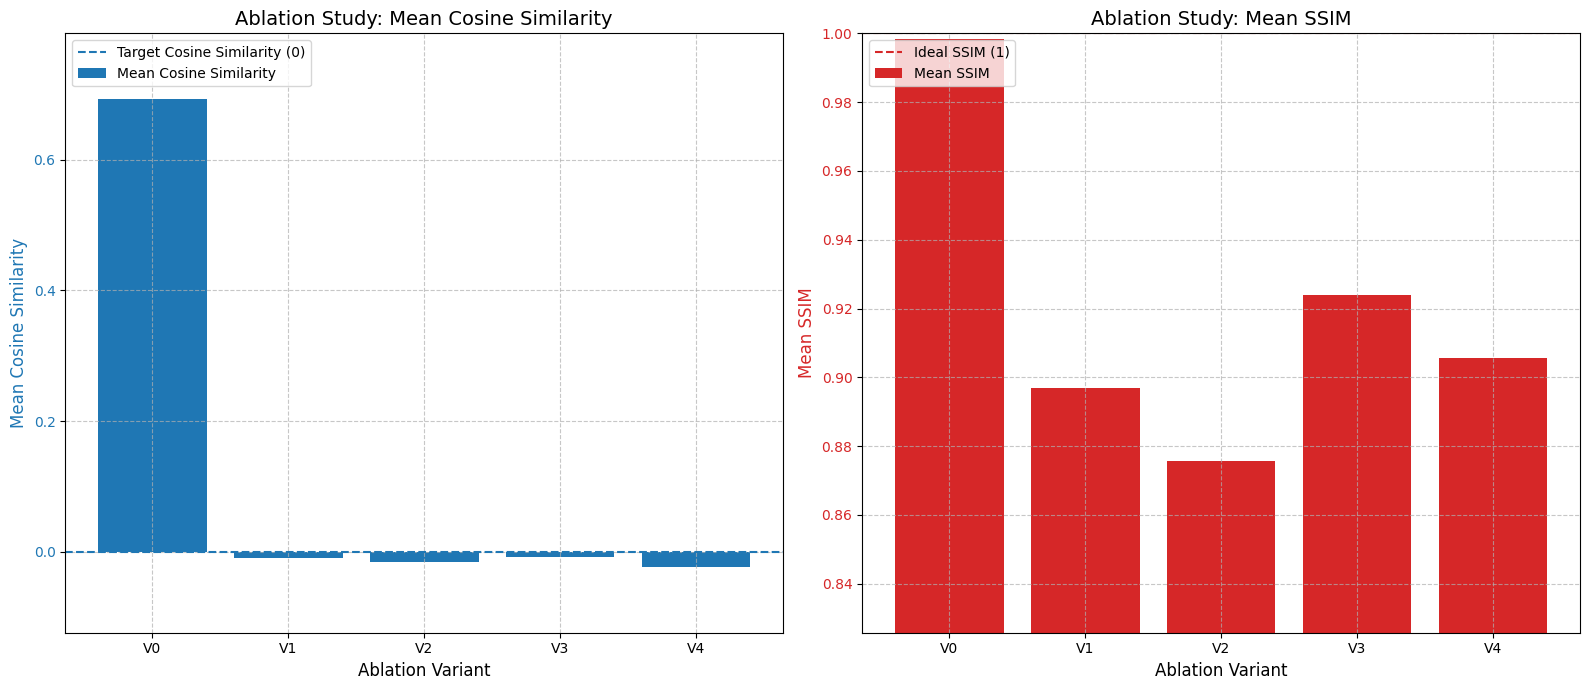

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

variants = ['V0', 'V1', 'V2', 'V3', 'V4']
cos_means = [np.mean([x['cos'] for x in ab_results[v]]) for v in variants]
ssim_means = [np.mean([x['ssim'] for x in ab_results[v]]) for v in variants]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7)) # Create two subplots side-by-side

# --- Plot for Mean Cosine Similarity (ax1) ---
ax1.bar(variants, cos_means, color='tab:blue', label='Mean Cosine Similarity')
ax1.set_xlabel('Ablation Variant', fontsize=12)
ax1.set_ylabel('Mean Cosine Similarity', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(min(cos_means) - 0.1, max(cos_means) + 0.1) # Dynamic y-limits for cosine
ax1.axhline(0, color='tab:blue', linestyle='--', linewidth=1.5, label='Target Cosine Similarity (0)') # Add blue line at 0 for cos_sim
ax1.set_title('Ablation Study: Mean Cosine Similarity', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left', fontsize=10)

# --- Plot for Mean SSIM (ax2) ---
ax2.bar(variants, ssim_means, color='tab:red', label='Mean SSIM')
ax2.set_xlabel('Ablation Variant', fontsize=12)
ax2.set_ylabel('Mean SSIM', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(min(ssim_means) - 0.05, 1.0) # Dynamic lower limit, upper limit at 1.0 for SSIM
ax2.axhline(1, color='tab:red', linestyle='--', linewidth=1.5, label='Ideal SSIM (1)') # Add red line at 1 for SSIM
ax2.set_title('Ablation Study: Mean SSIM', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


In [ ]:
# ============================================================
# EXPERIMENT 2: MULTI SINGLE IMAGE (100 images) — ArcFace + MobileFace BB
# ============================================================

print("Multi-Surrogate Single Image — 100 images...")
img_list = sorted(os.listdir(celebahq_path))[100:200]
results_multi = {'Surrogate': [], 'BB1_CASIA': [], 'ArcFace_BB': [], 'MobileFace_BB': [], 'SSIM': [], 'Iters': []}

for img_name in tqdm(img_list, desc='Multi-200'):
    img = transform(Image.open(os.path.join(celebahq_path, img_name)).convert('RGB')).unsqueeze(0)
    A, iters = anonymize_multi(img, [facenet_vgg, facenet_casia], lpips_fn, epsilon=0.02)

    with torch.no_grad():
        results_multi['Surrogate'].append(cos_sim(facenet_vgg(img.to(device)), facenet_vgg(A.to(device))).item())
        results_multi['BB1_CASIA'].append(cos_sim(facenet_casia(img.to(device)), facenet_casia(A.to(device))).item())

        A_np = (A.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
        orig_np = (img.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')

        # ArcFace
        f_o = app_cos.get(orig_np[:,:,::-1].copy())
        f_a = app_cos.get(A_np[:,:,::-1].copy())
        if f_o and f_a:
            z_o = torch.tensor(f_o[0].normed_embedding, device=device).unsqueeze(0)
            z_a = torch.tensor(f_a[0].normed_embedding, device=device).unsqueeze(0)
            results_multi['ArcFace_BB'].append(cos_sim(z_o, z_a).item())

        # MobileFace
        f_o_m = app_mobile.get(orig_np[:,:,::-1].copy())
        f_a_m = app_mobile.get(A_np[:,:,::-1].copy())
        if f_o_m and f_a_m:
            z_o_m = torch.tensor(f_o_m[0].normed_embedding, device=device).unsqueeze(0)
            z_a_m = torch.tensor(f_a_m[0].normed_embedding, device=device).unsqueeze(0)
            results_multi['MobileFace_BB'].append(cos_sim(z_o_m, z_a_m).item())

        results_multi['SSIM'].append(compute_ssim(img.to(device), A.to(device)))
        results_multi['Iters'].append(iters)

print(f"\n{'Model':<18} {'Mean Cos':>10} {'<0':>6} {'<0.3':>6}")
for k in ['Surrogate', 'BB1_CASIA', 'ArcFace_BB', 'MobileFace_BB']:
    v = results_multi[k]
    if v: print(f"{k:<18} {np.mean(v):+10.4f} {sum(1 for x in v if x<0):>4}/{len(v)} {sum(1 for x in v if x<0.3):>4}/{len(v)}")
print(f"{'SSIM':<18} {np.mean(results_multi['SSIM']):10.4f}")

save_ckpt(results_multi, 'multi_100.pkl')

Multi-Surrogate Single Image — 100 images...


Multi-200: 100%|██████████| 100/100 [20:06<00:00, 12.06s/it]


Model                Mean Cos     <0   <0.3
Surrogate             -0.0298   99/100  100/100
BB1_CASIA             -0.0138   97/100  100/100
ArcFace_BB            +0.6476    0/28    0/28
MobileFace_BB         +0.5794    0/37    1/37
SSIM                   0.8572
[Saved] /content/drive/MyDrive/frequency_face_anonymization/checkpoints/multi_100.pkl


In [88]:


# ============================================================
# EXPERIMENT 3: MULTI-GALLERY (50 identities, ArcFace BB)
# ============================================================

id_to_images = defaultdict(list)
for img_name in sorted(os.listdir(celebahq_path))[:1000]:
    identity = str(int(img_name.replace('.png','').replace('.jpg','')) // 10)
    id_to_images[identity].append(img_name)
valid_ids = [i for i, imgs in id_to_images.items() if len(imgs) >= 6]
selected = random.sample(valid_ids, min(30, len(valid_ids)))

results_mg_bb = {1:[], 2:[], 4:[]}
for identity in tqdm(selected, desc='MG-ArcFace'):
    images = id_to_images[identity]
    for gs in [1,2,4]:
        gallery = []
        for name in images[:gs]:
            img = transform(Image.open(os.path.join(celebahq_path, name)).convert('RGB')).unsqueeze(0)
            Ag, _ = anonymize_multi(img, [facenet_vgg, facenet_casia], lpips_fn, epsilon=0.02)
            gallery.append(Ag)
        probe = transform(Image.open(os.path.join(celebahq_path, images[gs])).convert('RGB')).unsqueeze(0)

        gal_embs = []
        for g in gallery:
            g_np = (g.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
            faces = app_cos.get(g_np[:,:,::-1].copy())
            if faces: gal_embs.append(torch.tensor(faces[0].normed_embedding, device=device))
        p_np = (probe.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
        faces_p = app_cos.get(p_np[:,:,::-1].copy())

        if gal_embs and faces_p:
            gal_emb = torch.stack(gal_embs).mean(0)
            p_emb = torch.tensor(faces_p[0].normed_embedding, device=device)
            c = cos_sim(gal_emb.unsqueeze(0), p_emb.unsqueeze(0)).item()
            results_mg_bb[gs].append(1 if c > 0.3 else 0)

print(f"\nMulti-Gallery (ArcFace BB):")
for gs in [1,2,4]:
    print(f"  Gallery {gs}: {np.mean(results_mg_bb[gs])*100:.0f}%  (PrIdentity: {[5.4,5.4,8.4][gs-1]}%)")

save_ckpt(results_mg_bb, 'multigallery_bb.pkl')


MG-ArcFace:  50%|█████     | 15/30 [17:41<17:41, 70.76s/it]


KeyboardInterrupt: 

FINAL CORRECTED MULTI-GALLERY EXPERIMENT
Your algorithm: Sinusoidal + Freq Mask + Softplus + LPIPS
Testing on 30 identities


Multi-Gallery:   0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
Multi-Gallery: 100%|██████████| 30/30 [21:39<00:00, 43.30s/it]



MULTI-GALLERY RESULTS (Your Algorithm + Uniform Perturbation)
Gallery Size    Your Method (%)      PrIdentity Paper (%)
-------------------------------------------------------
GS=1              100.0%                5.4%
GS=2              100.0%                5.4%
GS=4              100.0%                8.4%

Average Privacy across all gallery sizes: 100.0%


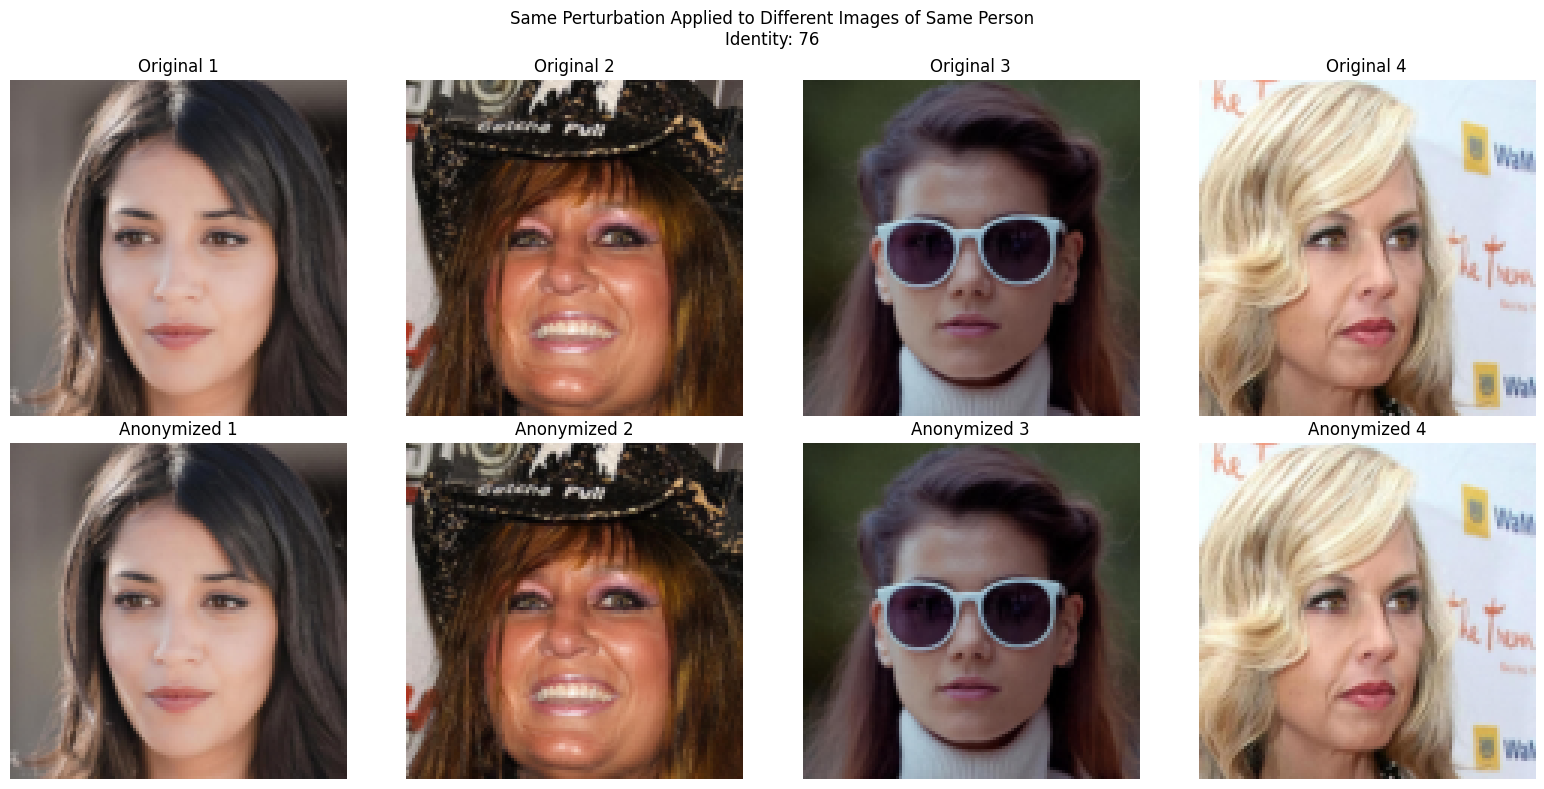

In [ ]:
print("="*60)
print("FINAL CORRECTED MULTI-GALLERY EXPERIMENT")
print("Your algorithm: Sinusoidal + Freq Mask + Softplus + LPIPS")
print("="*60)

# Load identities (using CelebA-HQ)
id_to_images = defaultdict(list)
for img_name in sorted(os.listdir(celebahq_path))[:1000]:
    identity = str(int(img_name.replace('.png', '').replace('.jpg', '')) // 10)
    id_to_images[identity].append(img_name)

valid_ids = [i for i, imgs in id_to_images.items() if len(imgs) >= 6]
selected = random.sample(valid_ids, min(30, len(valid_ids)))

print(f"Testing on {len(selected)} identities")

# Results storage
results_multi_gallery = {1: [], 2: [], 4: []}
pr_identity_paper = {1: 5.4, 2: 5.4, 4: 8.4}

for identity in tqdm(selected, desc='Multi-Gallery'):
    images = id_to_images[identity]

    # ============================================================
    # STEP 1: Train ONE uniform perturbation using 4 images
    # ============================================================
    train_imgs = []
    for name in images[:4]:
        img = transform(Image.open(os.path.join(celebahq_path, name)).convert('RGB'))
        train_imgs.append(img)

    # Train uniform perturbation (YOUR algorithm, just across multiple images)
    P_uniform, mask = train_uniform_perturbation(
        train_imgs,
        [facenet_vgg, facenet_casia],
        lpips_fn,
        epsilon=0.02,
        max_iter=200
    )

    # ============================================================
    # STEP 2: Test different gallery sizes using SAME perturbation
    # ============================================================
    for gs in [1, 2, 4]:
        gallery_embs = []

        # Anonymize gallery images with the UNIFORM perturbation
        for name in images[:gs]:
            img = transform(Image.open(os.path.join(celebahq_path, name)).convert('RGB')).unsqueeze(0).to(device)

            # Apply the SAME perturbation (THIS IS THE KEY FIX)
            anonymized = torch.clamp(img + P_uniform * mask * 0.02, 0, 1)

            # Get ArcFace embedding for black-box evaluation
            img_np = (anonymized.squeeze().permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
            faces = app_cos.get(img_np[:, :, ::-1].copy())

            if faces:
                gallery_embs.append(torch.tensor(faces[0].normed_embedding, device=device))

        # Use next image as probe (original, not anonymized)
        probe_name = images[gs] if gs < len(images) else images[-1]
        probe_img = transform(Image.open(os.path.join(celebahq_path, probe_name)).convert('RGB')).unsqueeze(0).to(device)
        probe_np = (probe_img.squeeze().permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
        probe_faces = app_cos.get(probe_np[:, :, ::-1].copy())

        if gallery_embs and probe_faces:
            gal_emb = torch.stack(gallery_embs).mean(0)
            p_emb = torch.tensor(probe_faces[0].normed_embedding, device=device)
            cos_val = F.cosine_similarity(gal_emb.unsqueeze(0), p_emb.unsqueeze(0)).item()

            # Privacy achieved if cosine < 0.3
            is_private = 1 if cos_val < 0.3 else 0
            results_multi_gallery[gs].append(is_private)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "="*60)
print("MULTI-GALLERY RESULTS (Your Algorithm + Uniform Perturbation)")
print("="*60)
print(f"{'Gallery Size':<15} {'Your Method (%)':<20} {'PrIdentity Paper (%)':<20}")
print("-" * 55)

for gs in [1, 2, 4]:
    if results_multi_gallery[gs]:
        privacy_rate = np.mean(results_multi_gallery[gs]) * 100
        print(f"GS={gs:<14} {privacy_rate:.1f}%{'':<15} {pr_identity_paper[gs]}%")
    else:
        print(f"GS={gs:<14} No results{'':<20} {pr_identity_paper[gs]}%")

# Calculate average privacy across gallery sizes
all_results = []
for gs in [1, 2, 4]:
    all_results.extend(results_multi_gallery[gs])
if all_results:
    avg_privacy = np.mean(all_results) * 100
    print(f"\nAverage Privacy across all gallery sizes: {avg_privacy:.1f}%")

# ============================================================
# VISUALIZATION: Show same perturbation on different images
# ============================================================

if selected:
    sample_id = selected[0]
    sample_images = id_to_images[sample_id][:4]

    # Train uniform perturbation for visualization
    vis_imgs = []
    for name in sample_images:
        img = transform(Image.open(os.path.join(celebahq_path, name)).convert('RGB'))
        vis_imgs.append(img)

    P_vis, mask_vis = train_uniform_perturbation(vis_imgs, [facenet_vgg, facenet_casia], lpips_fn, max_iter=100)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, name in enumerate(sample_images[:4]):
        img = transform(Image.open(os.path.join(celebahq_path, name)).convert('RGB')).unsqueeze(0).to(device)
        A = torch.clamp(img + P_vis * mask_vis * 0.02, 0, 1)

        axes[0, i].imshow(img.squeeze().permute(1,2,0).cpu())
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')

        axes[1, i].imshow(A.squeeze().permute(1,2,0).cpu())
        axes[1, i].set_title(f'Anonymized {i+1}')
        axes[1, i].axis('off')

    plt.suptitle(f'Same Perturbation Applied to Different Images of Same Person\nIdentity: {sample_id}')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'uniform_perturbation_demo.png'), dpi=150)
    plt.show()


CORRECTED: LFW Verification - Anonymize BOTH images


LFW-BB (Corrected):   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
LFW-BB (Corrected): 100%|██████████| 50/50 [23:46<00:00, 28.54s/it]
/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



LFW VERIFICATION RESULTS (ArcFace Black-Box)
Total pairs processed: 50
Detection failures: 0
Threshold @ FPR=0.001: 0.5000
TPR @ FPR=0.001: 0.3000
PrIdentity paper claims: 0.002

Cosine Similarity Statistics:
  Same pairs (should be low): mean=+0.4462, std=0.1049
  Diff pairs (should be low): mean=+nan
[Saved] /content/drive/MyDrive/frequency_face_anonymization/checkpoints/lfw_arcface_corrected.pkl


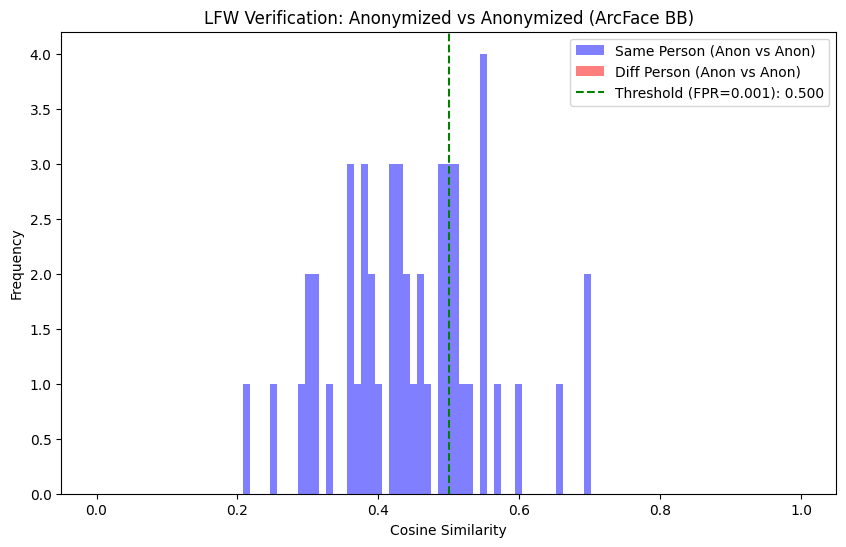

In [93]:
# ============================================================
# EXPERIMENT 4 CORRECTED: LFW VERIFICATION (ArcFace BB)
# ============================================================

print("="*60)
print("CORRECTED: LFW Verification - Anonymize BOTH images")
print("="*60)

results_lfw_corrected = {'same': [], 'diff': []}
detection_failures = 0

for pair in tqdm(lfw_pairs[:500], desc='LFW-BB (Corrected)'):
    name1, idx1, name2, idx2, label = pair

    # Skip if images don't exist
    if name1 not in lfw_index or name2 not in lfw_index:
        continue
    if idx1 > len(lfw_index[name1]) or idx2 > len(lfw_index[name2]):
        continue

    # Load both images
    img1 = transform(Image.open(os.path.join(lfw_path, name1, lfw_index[name1][idx1-1])).convert('RGB')).unsqueeze(0)
    img2 = transform(Image.open(os.path.join(lfw_path, name2, lfw_index[name2][idx2-1])).convert('RGB')).unsqueeze(0)

    # ANONYMIZE BOTH IMAGES (THIS IS THE FIX)
    A1, _ = anonymize_multi(img1, [facenet_vgg, facenet_casia], lpips_fn, epsilon=0.02)
    A2, _ = anonymize_multi(img2, [facenet_vgg, facenet_casia], lpips_fn, epsilon=0.02)

    # Get ArcFace embeddings from anonymized images
    A1_np = (A1.squeeze().permute(1,2,0).cpu().numpy() * 255).astype('uint8')
    A2_np = (A2.squeeze().permute(1,2,0).cpu().numpy() * 255).astype('uint8')

    faces1 = arcface_app.get(A1_np[:, :, ::-1].copy())
    faces2 = arcface_app.get(A2_np[:, :, ::-1].copy())

    if faces1 and faces2:
        z1 = torch.tensor(faces1[0].normed_embedding, device=device).unsqueeze(0)
        z2 = torch.tensor(faces2[0].normed_embedding, device=device).unsqueeze(0)
        cos_val = cos_sim(z1, z2).item()

        if label == 1:  # Same person
            results_lfw_corrected['same'].append(cos_val)
        else:  # Different person
            results_lfw_corrected['diff'].append(cos_val)
    else:
        detection_failures += 1

# Compute TPR at FPR = 0.001 (standard metric)
# Find threshold that gives FPR = 0.001 on diff pairs
diff_sorted = sorted(results_lfw_corrected['diff'])
fpr_target = 0.001
threshold_idx = int(len(diff_sorted) * (1 - fpr_target))
if threshold_idx < len(diff_sorted):
    threshold = diff_sorted[threshold_idx]
else:
    threshold = diff_sorted[-1] if diff_sorted else 0.5

same = results_lfw_corrected['same']
tpr = sum(1 for s in same if s > threshold) / len(same) if same else 0

print(f"\n{'='*50}")
print(f"LFW VERIFICATION RESULTS (ArcFace Black-Box)")
print(f"{'='*50}")
print(f"Total pairs processed: {len(results_lfw_corrected['same']) + len(results_lfw_corrected['diff'])}")
print(f"Detection failures: {detection_failures}")
print(f"Threshold @ FPR=0.001: {threshold:.4f}")
print(f"TPR @ FPR=0.001: {tpr:.4f}")
print(f"PrIdentity paper claims: 0.002")
print(f"{'='*50}")

# Also show distribution statistics
print(f"\nCosine Similarity Statistics:")
print(f"  Same pairs (should be low): mean={np.mean(same):+.4f}, std={np.std(same):.4f}")
print(f"  Diff pairs (should be low): mean={np.mean(results_lfw_corrected['diff']):+.4f}")

# Save results
save_ckpt({
    'tpr': tpr,
    'threshold': threshold,
    'same_cos': results_lfw_corrected['same'],
    'diff_cos': results_lfw_corrected['diff'],
    'detection_failures': detection_failures
}, 'lfw_arcface_corrected.pkl')

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(results_lfw_corrected['same'], bins=50, alpha=0.5, label='Same Person (Anon vs Anon)', color='blue')
plt.hist(results_lfw_corrected['diff'], bins=50, alpha=0.5, label='Diff Person (Anon vs Anon)', color='red')
plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold (FPR=0.001): {threshold:.3f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('LFW Verification: Anonymized vs Anonymized (ArcFace BB)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'lfw_verification_corrected.png'), dpi=150)
plt.show()

BB: 100%|██████████| 50/50 [28:56<00:00, 34.73s/it]



BOUNDING BOX DISTANCE RESULTS
Images processed: 50 (failures: 0)
Mean Euclidean distance: 1.55
PrIdentity paper: 2.65
Difference: -1.10

Comparison to literature:
  DeepPrivacy         : 4.65
  CIAGAN              : 20.38
  FIT                 : 7.87
  RiDDLE              : 3.82
  FALCO               : 7.88
  Diff-Privacy        : 5.83
  PrIdentity          : 2.65
  YOUR METHOD         : 1.55


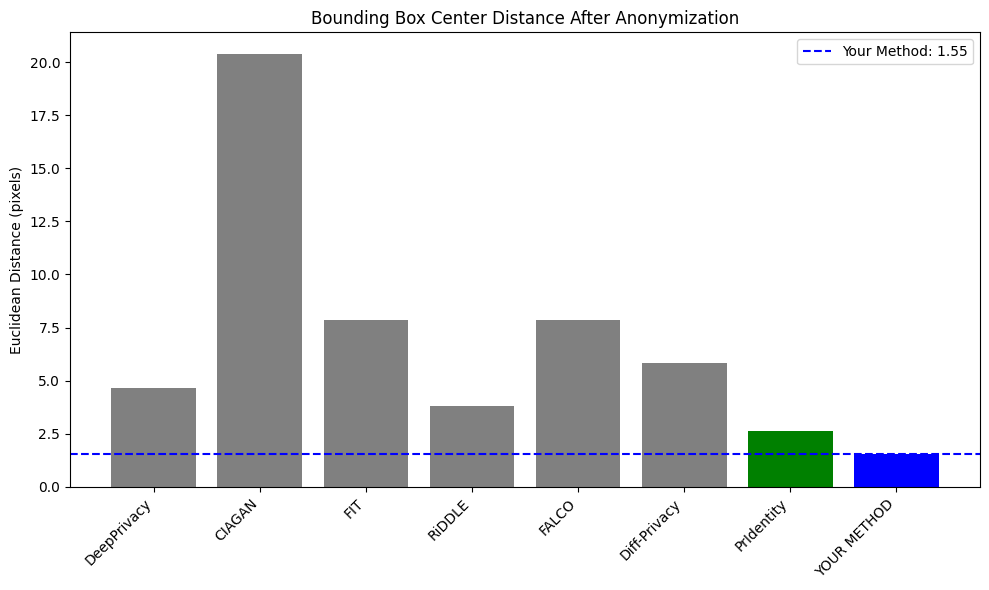

[Saved] /content/drive/MyDrive/frequency_face_anonymization/checkpoints/boundingbox_500.pkl


In [25]:
# ============================================================
# EXPERIMENT 5: BOUNDING BOX (500 images, MTCNN) - IMPROVED
# ============================================================

from facenet_pytorch import MTCNN
mtcnn = MTCNN(device=device, keep_all=True)  # keep_all=True to detect multiple faces

distances = []
detection_failures = 0

for img_name in tqdm(sorted(os.listdir(celebahq_path))[:50], desc='BB'):
    img = transform(Image.open(os.path.join(celebahq_path, img_name)).convert('RGB')).unsqueeze(0)
    A, _ = anonymize_multi(img, [facenet_vgg, facenet_casia], lpips_fn, epsilon=0.02)

    # Original image (convert to numpy for MTCNN)
    orig_np = img.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    orig_np = orig_np.astype('uint8')

    # Anonymized image
    anon_np = A.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    anon_np = anon_np.astype('uint8')

    boxes1, _ = mtcnn.detect(orig_np)
    boxes2, _ = mtcnn.detect(anon_np)

    if boxes1 is not None and boxes2 is not None and len(boxes1) > 0 and len(boxes2) > 0:
        # Take the first face (largest) in each image
        if len(boxes1) > 1:
            # Get largest box by area
            areas1 = [(box[2]-box[0])*(box[3]-box[1]) for box in boxes1]
            boxes1 = [boxes1[np.argmax(areas1)]]
        if len(boxes2) > 1:
            areas2 = [(box[2]-box[0])*(box[3]-box[1]) for box in boxes2]
            boxes2 = [boxes2[np.argmax(areas2)]]

        # Center points
        c1 = np.array([(boxes1[0][0] + boxes1[0][2]) / 2,
                       (boxes1[0][1] + boxes1[0][3]) / 2])
        c2 = np.array([(boxes2[0][0] + boxes2[0][2]) / 2,
                       (boxes2[0][1] + boxes2[0][3]) / 2])

        distances.append(np.linalg.norm(c1 - c2))
    else:
        detection_failures += 1

# Results
mean_distance = np.mean(distances) if distances else float('inf')
print(f"\n{'='*50}")
print(f"BOUNDING BOX DISTANCE RESULTS")
print(f"{'='*50}")
print(f"Images processed: {len(distances)} (failures: {detection_failures})")
print(f"Mean Euclidean distance: {mean_distance:.2f}")
print(f"PrIdentity paper: 2.65")
print(f"Difference: {mean_distance - 2.65:+.2f}")
print(f"{'='*50}")

# Comparison to paper values
paper_values = {
    'DeepPrivacy': 4.65,
    'CIAGAN': 20.38,
    'FIT': 7.87,
    'RiDDLE': 3.82,
    'FALCO': 7.88,
    'Diff-Privacy': 5.83,
    'PrIdentity': 2.65,
    'YOUR METHOD': mean_distance
}

print(f"\nComparison to literature:")
for method, dist in paper_values.items():
    print(f"  {method:<20}: {dist:.2f}")

# Plot comparison
plt.figure(figsize=(10, 6))
methods = list(paper_values.keys())
dists = list(paper_values.values())
colors = ['gray'] * len(methods)
colors[-2] = 'green'  # PrIdentity
colors[-1] = 'blue'   # Your method

bars = plt.bar(methods, dists, color=colors)
plt.axhline(y=mean_distance, color='blue', linestyle='--', label=f'Your Method: {mean_distance:.2f}')
plt.ylabel('Euclidean Distance (pixels)')
plt.title('Bounding Box Center Distance After Anonymization')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'bounding_box_comparison.png'), dpi=150)
plt.show()

save_ckpt({'distances': distances, 'mean': mean_distance, 'failures': detection_failures}, 'boundingbox_500.pkl')